<a href="https://colab.research.google.com/github/muajnstu/Plan_Crash_Prediction_-_Topic_Modelling/blob/main/D1_Implementation_followed_by_a_data_balancing_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pipeline Overview**
1. Install & Import
2. All Function Definitions
3. Data Loading & Preprocessing
4. TF-IDF Vectorisation + LSA
5. KMeans Clustering per Sentiment Class
6. Re-clustering (Synthetic-Minimising Strategy)
7. Cluster Filtering & Label Assignment
8. Applying SMOTE
9. Train / Test Split & Scaling
10. Classic ML — Train
11. Deep Learning — Train (LSTM / GRU / CNN / BiLSTM)
12. Transformer — Train (BERT / RoBERTa / DistilBERT / ALBERT)
13. Results — Compare & Summarise

**Install Dependencies**

In [ ]:
!pip install -q imbalanced-learn xgboost lightgbm transformers torch

**Imports**

In [ ]:
import warnings, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from collections import Counter
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    silhouette_score
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Perceptron, SGDClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier,
    BaggingClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC, LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Conv1D, GlobalMaxPooling1D, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print('All imports successful.')

All imports successful.


**Global Constants**

In [ ]:
# ── Reproducibility
RANDOM_STATE   = 42

# ── TF-IDF / LSA
TFIDF_MAX_FEAT = 1000
LSA_COMPONENTS = 100

# ── KMeans / clustering
KMEANS_INIT    = 10          # n_init for KMeans
MIN_CLUSTER_RATIO = 0.40     # drop clusters below 40% of median size
ABS_MIN_CLUSTER   = 50       # absolute floor for any cluster

# ── Train / test split
TEST_SIZE      = 0.20
VAL_SIZE       = 0.10

# ── Deep Learning
MAX_WORDS      = 20_000      # Tokenizer vocabulary size
MAX_LEN        = 100         # Padded sequence length
EMBED_DIM      = 64          # Embedding dimension
DL_EPOCHS      = 5
DL_BATCH_SIZE  = 32

# ── Transformer
TRANSFORMER_MAX_LEN   = 128
TRANSFORMER_EPOCHS    = 3
TRANSFORMER_BATCH     = 8
TRANSFORMER_LR        = 2e-5

# ── Label map
LABEL_MAP      = {0: 'Positive', 1: 'Negative', 2: 'Mixed'}

# ── classifiers that require scaled input
NEEDS_SCALE = {
    'LogisticRegression', 'RidgeClassifier', 'SGDClassifier', 'Perceptron',
    'GaussianNB', 'BernoulliNB', 'KNeighborsClassifier',
    'LinearDiscriminantAnalysis', 'QuadraticDiscriminantAnalysis',
    'LinearSVC', 'SVC_RBF', 'MLPClassifier',
}

**All Function Definitions**
> Every helper used downstream is defined here. Run this cell once before executing any later section.

In [ ]:
# TEXT PREPROCESSING

_stop_words  = set(stopwords.words('english'))
_lemmatizer  = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """Lowercase → strip non-alpha → remove stopwords → lemmatise."""
    text   = str(text).lower()
    text   = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [_lemmatizer.lemmatize(w) for w in tokens if w not in _stop_words]
    return ' '.join(tokens)

# CLUSTERING HELPERS

def synthetic_count(counts) -> int:
    """Estimate total SMOTE synthetic samples needed to equalise all clusters."""
    m = max(counts)
    return sum(m - c for c in counts)


def plot_elbow_silhouette(X: np.ndarray, title: str) -> int:
    """
    Plot WCSS (elbow) and silhouette score for k = 2..10.
    Returns the best k according to silhouette.
    """
    wcss, sil_scores, k_range = [], [], range(2, 11)
    for k in k_range:
        km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=KMEANS_INIT)
        labels = km.fit_predict(X)
        wcss.append(km.inertia_)
        sil_scores.append(silhouette_score(X, labels, sample_size=min(2000, len(X))))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(k_range, wcss, marker='o')
    ax1.set_title(f'{title} — WCSS (Elbow)')
    ax1.set_xlabel('k'); ax1.set_ylabel('WCSS')

    ax2.plot(k_range, sil_scores, marker='s', color='darkorange')
    ax2.set_title(f'{title} — Silhouette Score')
    ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette')

    plt.tight_layout(); plt.show()
    best_k = list(k_range)[sil_scores.index(max(sil_scores))]
    print(f'  Best k by silhouette: {best_k} (score={max(sil_scores):.3f})')
    return best_k


def split_large_clusters(
    X: np.ndarray,
    labels: np.ndarray,
    min_cluster_size: int = ABS_MIN_CLUSTER
) -> np.ndarray:
    """
    Iteratively split the largest cluster until no cluster exceeds the
    second-largest. Uses silhouette to pick the best sub-k.
    """
    new_labels = np.array(labels, dtype=object)
    for iteration in range(1, 50):
        unique, counts = np.unique(new_labels, return_counts=True)
        order          = np.argsort(-counts)
        unique, counts = unique[order], counts[order]
        if len(unique) < 2 or counts[0] <= counts[1]:
            break

        largest_name, largest_size, second_size = unique[0], counts[0], counts[1]
        k_min = math.ceil(largest_size / second_size)
        k_max = k_min + 2
        idx   = np.where(new_labels == largest_name)[0]
        X_sub = X[idx]
        print(f'Iter {iteration}: splitting "{largest_name}" '
              f'(n={largest_size}) into k={k_min}…{k_max} (second={second_size})')

        best_k, best_score, best_sublabels = None, -np.inf, None
        for k in range(k_min, k_max + 1):
            if k >= len(idx): break
            km        = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=KMEANS_INIT)
            sub_lbl   = km.fit_predict(X_sub)
            sub_counts = np.bincount(sub_lbl)
            if sub_counts.min() < min_cluster_size:
                print(f'  k={k} rejected: smallest={sub_counts.min()} < {min_cluster_size}')
                continue
            sil = silhouette_score(X_sub, sub_lbl, sample_size=min(2000, len(X_sub)))
            print(f'  k={k}: sizes={sorted(sub_counts, reverse=True)}, sil={sil:.3f}')
            if sil > best_score:
                best_score, best_k, best_sublabels = sil, k, sub_lbl

        if best_k is None:
            print(f'  No valid split for "{largest_name}" — stopping.'); break

        for i, sub in zip(idx, best_sublabels):
            new_labels[i] = f'{largest_name}_{sub}'
        new_counts = np.bincount(best_sublabels)
        print(f'  => k={best_k} (sil={best_score:.3f}), sizes={sorted(new_counts, reverse=True)}')
        print(f'  => Synthetic count: {synthetic_count(np.unique(new_labels, return_counts=True)[1]):,}\n')

    return new_labels

# TRAIN / TEST SPLIT & SCALING


def split_and_scale(
    X: np.ndarray,
    y: np.ndarray,
    test_size: float = TEST_SIZE,
    val_size: float  = VAL_SIZE
):
    """
    Stratified 80 / 10 / 10 split (train / val / test) + StandardScaler.

    Returns
    -------
    X_train, X_val, X_test       : raw (unscaled) splits
    X_train_sc, X_val_sc, X_test_sc : scaled splits
    y_train, y_val, y_test       : label arrays
    scaler                       : fitted StandardScaler
    """
    # First split: train+val vs test
    X_tv, X_test, y_tv, y_test = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )
    # Second split: train vs val
    val_frac = val_size / (1.0 - test_size)          # relative fraction
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=val_frac, random_state=RANDOM_STATE, stratify=y_tv
    )

    scaler      = StandardScaler()
    X_train_sc  = scaler.fit_transform(X_train)
    X_val_sc    = scaler.transform(X_val)
    X_test_sc   = scaler.transform(X_test)

    print(f'Train : {X_train_sc.shape} | class dist: {Counter(y_train)}')
    print(f'Val   : {X_val_sc.shape}   | class dist: {Counter(y_val)}')
    print(f'Test  : {X_test_sc.shape}  | class dist: {Counter(y_test)}')

    return (X_train, X_val, X_test,
            X_train_sc, X_val_sc, X_test_sc,
            y_train, y_val, y_test,
            scaler)

# METRICS

def calculate_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray | None,
    model_name: str
) -> dict:
    """
    Compute accuracy, precision, recall, weighted-F1, and macro-AUC.
    y_proba : (n_samples, n_classes) probability matrix, or None to skip AUC.

    Returns a dict suitable for pd.DataFrame.from_dict(orient='index').
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    if y_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        except ValueError:
            auc = float('nan')
    else:
        auc = float('nan')

    return {
        'Model'    : model_name,
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1'       : round(f1,   4),
        'AUC'      : round(auc,  4),
    }

#   CLASSIC ML

def build_classifiers() -> dict:
    """Return a fresh dict of (name → unfitted classifier)."""
    return {
        # Linear
        'LogisticRegression'         : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
        'RidgeClassifier'            : RidgeClassifier(class_weight='balanced'),
        'SGDClassifier'              : SGDClassifier(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
        'Perceptron'                 : Perceptron(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
        # Naive Bayes
        'GaussianNB'                 : GaussianNB(),
        'BernoulliNB'                : BernoulliNB(),
        # Distance
        'KNeighborsClassifier'       : KNeighborsClassifier(n_neighbors=5),
        # Discriminant
        'LinearDiscriminantAnalysis' : LinearDiscriminantAnalysis(),
        'QuadraticDiscriminantAnalysis': QuadraticDiscriminantAnalysis(reg_param=0.1),
        # Tree
        'DecisionTreeClassifier'     : DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
        #'ExtraTreeClassifier'        : ExtraTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
        # Ensemble
        'RandomForestClassifier'     : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1),
        'ExtraTreesClassifier'       : ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1),
        'AdaBoostClassifier'         : AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
        'GradientBoostingClassifier' : GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
        'BaggingClassifier'          : BaggingClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
        # SVM
        'LinearSVC'                  : LinearSVC(max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced'),
        'SVC_RBF'                    : SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE, class_weight='balanced'),
        # Gradient boosting (external)
        'XGBClassifier'              : XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0),
        'LGBMClassifier'             : LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced', verbosity=-1),
        # Neural
        'MLPClassifier'              : MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300, random_state=RANDOM_STATE),
    }


def run_classic_ml(
    X_train: np.ndarray, X_test: np.ndarray,
    X_train_sc: np.ndarray, X_test_sc: np.ndarray,
    y_train: np.ndarray, y_test: np.ndarray
) -> dict:
    """
    Train all classic ML classifiers and collect metrics.
    Prints a one-line summary per model; full results returned as a dict.

    Returns
    -------
    dict  {model_name: metrics_dict}
    """
    classifiers = build_classifiers()
    results     = {}

    print(f'{"Model":<36}  {"Acc":>6}  {"F1":>6}  {"AUC":>6}  {"Time":>6}')
    print('-' * 65)

    for name, clf in classifiers.items():
        Xtr = X_train_sc if name in NEEDS_SCALE else X_train
        Xte = X_test_sc  if name in NEEDS_SCALE else X_test

        t0 = time.time()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            clf.fit(Xtr, y_train)
            y_pred = clf.predict(Xte)
        elapsed = time.time() - t0

        # Probability matrix for AUC (not all classifiers support predict_proba)
        y_proba = None
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            if hasattr(clf, 'predict_proba'):
                y_proba = clf.predict_proba(Xte)
            elif hasattr(clf, 'decision_function'):
                df = clf.decision_function(Xte)
                # Convert decision scores to pseudo-probabilities via softmax
                e  = np.exp(df - df.max(axis=1, keepdims=True))
                y_proba = e / e.sum(axis=1, keepdims=True)

        m = calculate_metrics(y_test, y_pred, y_proba, name)
        m['Time(s)'] = round(elapsed, 2)
        results[name] = m

        print(f'{name:<36}  {m["Accuracy"]:>6.4f}  {m["F1"]:>6.4f}  '
              f'{m["AUC"]:>6.4f}  {elapsed:>5.1f}s')

    return results

# DEEP LEARNING  (Keras)

def prepare_dl_data(
    X_train_raw, X_val_raw, X_test_raw,
    y_train: np.ndarray, y_val: np.ndarray, y_test: np.ndarray
):
    """
    Tokenise + pad text sequences for Keras DL models.
    X_* inputs should be arrays / Series of raw (pre-cleaned) text strings.

    Returns
    -------
    X_train_seq, X_val_seq, X_test_seq  : padded integer sequences
    y_train, y_val, y_test              : numpy label arrays
    tokenizer                           : fitted Keras Tokenizer
    """
    tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
    tokenizer.fit_on_texts(X_train_raw)

    def _seq(X):
        return pad_sequences(tokenizer.texts_to_sequences(X), maxlen=MAX_LEN)

    X_train_seq = _seq(X_train_raw)
    X_val_seq   = _seq(X_val_raw)
    X_test_seq  = _seq(X_test_raw)

    if hasattr(y_train, 'values'): y_train = y_train.values
    if hasattr(y_val,   'values'): y_val   = y_val.values
    if hasattr(y_test,  'values'): y_test  = y_test.values

    print(f'DL sequences — train: {X_train_seq.shape}, val: {X_val_seq.shape}, test: {X_test_seq.shape}')
    return X_train_seq, X_val_seq, X_test_seq, y_train, y_val, y_test, tokenizer


def create_lstm() -> Sequential:
    return Sequential([
        Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
        LSTM(128),
        Dense(3, activation='softmax')
    ])

def create_gru() -> Sequential:
    return Sequential([
        Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
        GRU(128),
        Dense(3, activation='softmax')
    ])

def create_cnn() -> Sequential:
    return Sequential([
        Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
        Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(3, activation='softmax')
    ])

def create_bilstm() -> Sequential:
    return Sequential([
        Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(128)),
        Dense(3, activation='softmax')
    ])


def train_dl_model(
    name: str,
    model_fn,
    X_train_seq: np.ndarray, y_train: np.ndarray,
    X_val_seq: np.ndarray,   y_val: np.ndarray,
    X_test_seq: np.ndarray,  y_test: np.ndarray
) -> dict:
    """
    Compile, train, and evaluate one Keras model.
    Returns a metrics dict (same shape as calculate_metrics output).
    """
    print(f'\nTraining {name}...')
    model = model_fn()
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    model.fit(
        X_train_seq, y_train,
        epochs=DL_EPOCHS,
        batch_size=DL_BATCH_SIZE,
        validation_data=(X_val_seq, y_val),
        verbose=1
    )
    y_proba = model.predict(X_test_seq, verbose=0)
    y_pred  = np.argmax(y_proba, axis=1)
    return calculate_metrics(y_test, y_pred, y_proba, name)


def run_dl_models(
    X_train_seq, y_train_dl,
    X_val_seq,   y_val_dl,
    X_test_seq,  y_test_dl
) -> dict:
    """
    Train all four Keras DL architectures and return a results dict.

    Returns
    -------
    dict  {model_name: metrics_dict}
    """
    dl_architectures = {
        'LSTM'  : create_lstm,
        'GRU'   : create_gru,
        'CNN'   : create_cnn,
        'BiLSTM': create_bilstm,
    }
    dl_results = {}
    for name, fn in dl_architectures.items():
        metrics = train_dl_model(
            name, fn,
            X_train_seq, y_train_dl,
            X_val_seq,   y_val_dl,
            X_test_seq,  y_test_dl
        )
        dl_results[name] = metrics
    return dl_results

# TRANSFORMER  (PyTorch / HuggingFace)

class TorchTextDataset(torch.utils.data.Dataset):
    """Minimal Dataset wrapper for HuggingFace Trainer."""
    def __init__(self, encodings, labels):
        if hasattr(labels, 'values'): labels = labels.values
        self.labels    = torch.tensor(labels, dtype=torch.long)
        self.encodings = encodings

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)


def _tokenize_for_transformer(tokenizer, X, max_length: int = TRANSFORMER_MAX_LEN):
    """Tokenise a text array and return HuggingFace BatchEncoding."""
    return tokenizer(
        list(X),
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )


def train_pytorch_transformer(
    model_name: str,
    checkpoint: str,
    num_labels: int,
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    max_length: int = TRANSFORMER_MAX_LEN
) -> dict:
    """
    Load a pre-trained transformer, fine-tune via HuggingFace Trainer,
    and evaluate on the test split.

    Returns
    -------
    dict  {metric_name: value}  (same shape as calculate_metrics output)
    """
    print(f'\n{"="*70}\nTRAINING {model_name}\n{"="*70}')
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model     = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=num_labels
    )
    model.config.problem_type = 'single_label_classification'

    train_ds = TorchTextDataset(_tokenize_for_transformer(tokenizer, X_train, max_length), y_train)
    val_ds   = TorchTextDataset(_tokenize_for_transformer(tokenizer, X_val,   max_length), y_val)
    test_ds  = TorchTextDataset(_tokenize_for_transformer(tokenizer, X_test,  max_length), y_test)

    training_args = TrainingArguments(
        output_dir=f'./results_{model_name.lower()}',
        num_train_epochs=TRANSFORMER_EPOCHS,
        per_device_train_batch_size=TRANSFORMER_BATCH,
        per_device_eval_batch_size=TRANSFORMER_BATCH,
        learning_rate=TRANSFORMER_LR,
        warmup_ratio=0.1,
        eval_strategy='epoch',
        save_strategy='no',
        logging_strategy='epoch',
        max_grad_norm=1.0,
        report_to='none'
    )
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds
    )
    trainer.train()

    test_outputs = trainer.predict(test_ds)
    logits  = test_outputs.predictions
    y_pred  = np.argmax(logits, axis=1)
    probs   = torch.nn.functional.softmax(torch.tensor(logits), dim=1)
    y_proba = torch.nan_to_num(probs).cpu().numpy()

    return calculate_metrics(y_test if not hasattr(y_test, 'values') else y_test.values,
                             y_pred, y_proba, model_name)


def run_transformer_models(
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    num_labels: int
) -> dict:
    """
    Fine-tune all configured transformer checkpoints and return a results dict.

    Returns
    -------
    dict  {model_name: metrics_dict}
    """
    transformer_checkpoints = {
        'BERT'      : 'bert-base-uncased',
        'RoBERTa'   : 'roberta-base',
        'DistilBERT': 'distilbert-base-uncased',
        'ALBERT'    : 'albert-base-v2',
        # 'DeBERTa' : 'microsoft/deberta-v3-base',  # uncomment if GPU available
    }
    transformer_results = {}
    for name, ckpt in transformer_checkpoints.items():
        metrics = train_pytorch_transformer(
            name, ckpt, num_labels,
            X_train, y_train,
            X_val,   y_val,
            X_test,  y_test
        )
        transformer_results[name] = metrics
    return transformer_results


# REPORTING

def build_results_df(all_results: dict) -> pd.DataFrame:
    """Convert the combined results dict to a tidy DataFrame sorted by AUC."""
    df = pd.DataFrame.from_dict(all_results, orient='index')
    df.index.name = 'Model'
    df = df.drop(columns=['Model'], errors='ignore')   # index already holds the name
    return df.sort_values('AUC', ascending=False)


def plot_model_comparison(results_df: pd.DataFrame, metric: str = 'F1', top_n: int = 15):
    """Horizontal bar chart for the top-N models by the given metric."""
    top = results_df.sort_values(metric, ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top.index[::-1], top[metric][::-1], color='steelblue')
    ax.set_xlabel(metric)
    ax.set_title(f'Top-{top_n} Models — {metric} (CrFB + SMOTE)')
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, top[metric][::-1]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout(); plt.show()


def plot_confusion_matrix(y_true, y_pred, model_name: str,
                          class_names=('Positive', 'Negative', 'Mixed')):
    """Plot a labelled confusion matrix for the given predictions."""
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout(); plt.show()


print('All functions defined.')

All functions defined.


**Data Loading & Preprocessing**

In [ ]:
url = 'https://raw.githubusercontent.com/muajnstu/Plan_Crash_Prediction_-_Topic_Modelling/refs/heads/main/Dataset_1.csv'
df  = pd.read_csv(url)
print(df.head())
print('\nSentiment distribution:')
print(df['sentiment'].value_counts())

                                              review sentiment
0  Worst experience at Dhaka airport. Delayed fli...  Negative
1  Good value for money. Somethimes you might con...  Positive
2  Very good airlines ever i see. Good service fo...  Positive
3  I naver used Biman Bangladesh and it was first...  Positive
4  I have travelled from London to Dhaka direct f...  Negative

Sentiment distribution:
sentiment
Negative    3843
Positive    2386
Mixed       1896
Name: count, dtype: int64


In [ ]:
df_cleaned = df.copy()

# Drop duplicates
before = df_cleaned.shape
df_cleaned = df_cleaned.drop_duplicates()
print(f'Duplicates removed: {before[0] - df_cleaned.shape[0]} rows')
print(f'Shape: {before} → {df_cleaned.shape}')

# Clean text
df_cleaned['review'] = df_cleaned['review'].apply(clean_text)
print('\nSample cleaned reviews:')
print(df_cleaned['review'].head())

Duplicates removed: 2 rows
Shape: (8125, 2) → (8123, 2)

Sample cleaned reviews:
0    worst experience dhaka airport delayed flight ...
1    good value money somethimes might consider ove...
2    good airline ever see good service food qualit...
3    naver used biman bangladesh first time tried s...
4    travelled london dhaka direct flight due covid...
Name: review, dtype: object


**TF-IDF Vectorisation + LSA (Dimensionality Reduction)**

In [ ]:
tfidf = TfidfVectorizer(max_features=TFIDF_MAX_FEAT, stop_words=list(_stop_words))
X_vectorized = tfidf.fit_transform(df_cleaned['review'])
print('TF-IDF shape:', X_vectorized.shape)

svd = TruncatedSVD(n_components=LSA_COMPONENTS, random_state=RANDOM_STATE)
X_reduced = svd.fit_transform(X_vectorized)
explained = svd.explained_variance_ratio_.sum()
print(f'LSA: {LSA_COMPONENTS} components explain {explained:.1%} of variance')
print('Reduced shape:', X_reduced.shape)

TF-IDF shape: (8123, 1000)
LSA: 100 components explain 33.6% of variance
Reduced shape: (8123, 100)


**Clustering per Sentiment Class**

In [ ]:
y_labels = df_cleaned['sentiment'].values

X_pos = X_reduced[y_labels == 'Positive']
X_neg = X_reduced[y_labels == 'Negative']
X_neu = X_reduced[y_labels == 'Mixed']

print('Positive:', X_pos.shape)
print('Negative:', X_neg.shape)
print('Mixed   :', X_neu.shape)

Positive: (2386, 100)
Negative: (3843, 100)
Mixed   : (1894, 100)


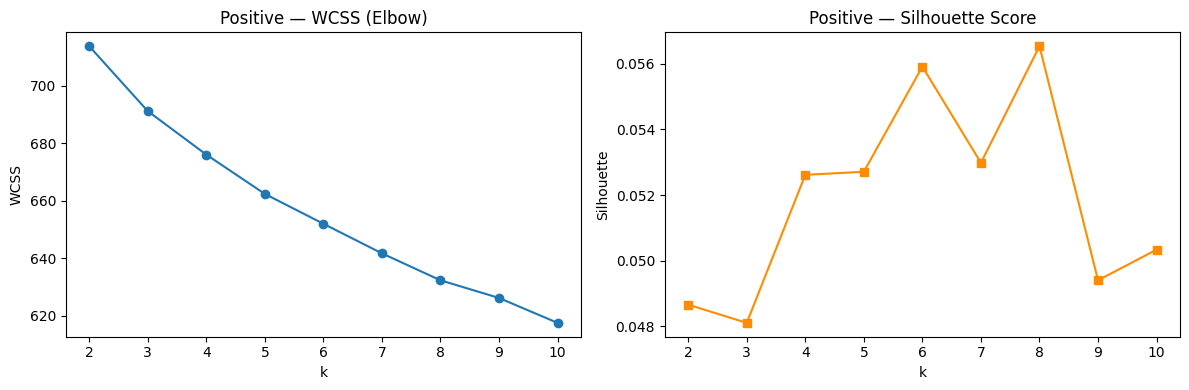

  Best k by silhouette: 8 (score=0.057)


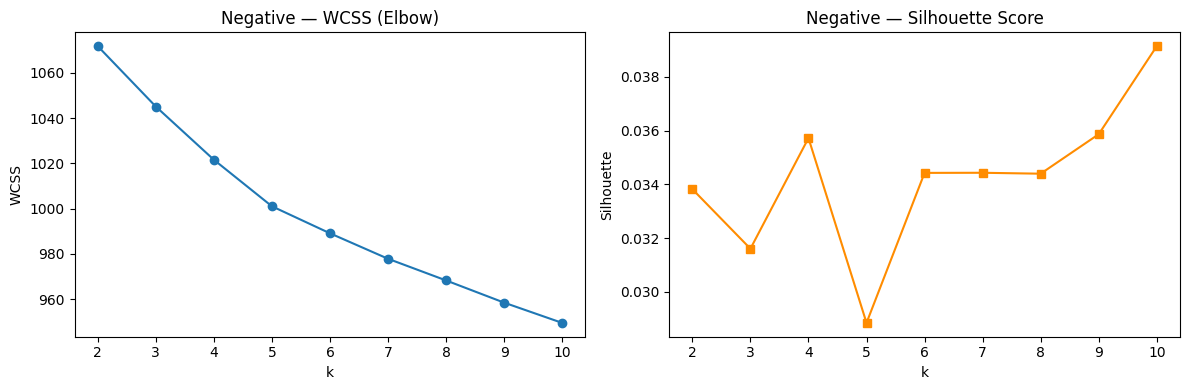

  Best k by silhouette: 10 (score=0.039)


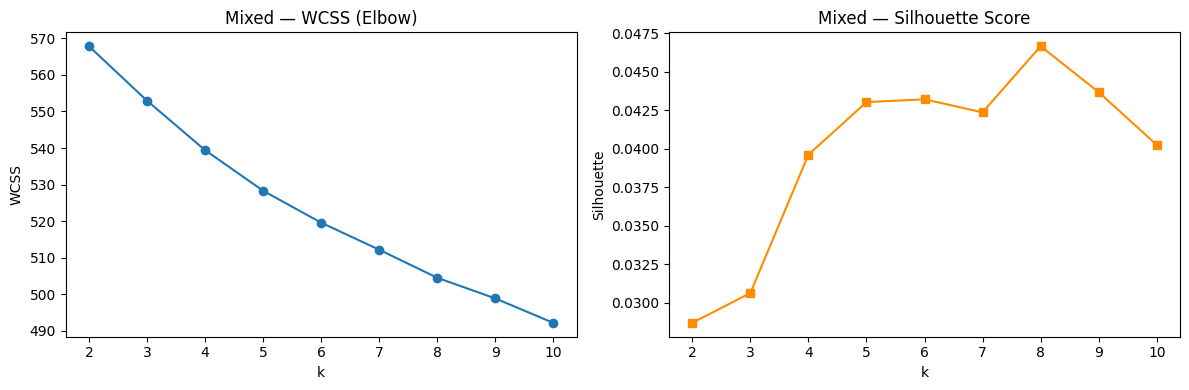

  Best k by silhouette: 8 (score=0.047)


In [ ]:
# Elbow + silhouette — inspect plots before proceeding
best_k_pos = plot_elbow_silhouette(X_pos, 'Positive')
best_k_neg = plot_elbow_silhouette(X_neg, 'Negative')
best_k_neu = plot_elbow_silhouette(X_neu, 'Mixed')

In [ ]:
# Override any k here if the plots suggest a different choice
n_clusters_positive = best_k_pos
n_clusters_negative = best_k_neg
n_clusters_neutral  = best_k_neu

km_pos = KMeans(n_clusters=n_clusters_positive, random_state=RANDOM_STATE, n_init=KMEANS_INIT)
km_neg = KMeans(n_clusters=n_clusters_negative, random_state=RANDOM_STATE, n_init=KMEANS_INIT)
km_neu = KMeans(n_clusters=n_clusters_neutral,  random_state=RANDOM_STATE, n_init=KMEANS_INIT)

labels_pos = km_pos.fit_predict(X_pos)
labels_neg = km_neg.fit_predict(X_neg)
labels_neu = km_neu.fit_predict(X_neu)

print('Cluster distribution:')
print('  Positive:', np.bincount(labels_pos))
print('  Negative:', np.bincount(labels_neg))
print('  Mixed   :', np.bincount(labels_neu))

Cluster distribution:
  Positive: [ 82 427 289  63 328 301 660 236]
  Negative: [119 558 196 676 345 334 158 563 470 424]
  Mixed   : [102 217 199 317 280 198 495  86]


**Cluster + Re-clustering**

In [ ]:
df_pos = pd.DataFrame(X_pos); df_pos['target'] = 'Positive'; df_pos['Cluster_Label'] = ['Positive_' + str(i+1) for i in labels_pos]
df_neg = pd.DataFrame(X_neg); df_neg['target'] = 'Negative'; df_neg['Cluster_Label'] = ['Negative_' + str(i+1) for i in labels_neg]
df_neu = pd.DataFrame(X_neu); df_neu['target'] = 'Mixed';    df_neu['Cluster_Label'] = ['Mixed_'    + str(i+1) for i in labels_neu]

final_df = pd.concat([df_pos, df_neg, df_neu], ignore_index=True)
print('Cluster distribution (initial):')
print(final_df['Cluster_Label'].value_counts())
print(f'\nInitial synthetic count estimate: {synthetic_count(final_df["Cluster_Label"].value_counts().values):,}')

Cluster distribution (initial):
Cluster_Label
Negative_4     676
Positive_7     660
Negative_8     563
Negative_2     558
Mixed_7        495
Negative_9     470
Positive_2     427
Negative_10    424
Negative_5     345
Negative_6     334
Positive_5     328
Mixed_4        317
Positive_6     301
Positive_3     289
Mixed_5        280
Positive_8     236
Mixed_2        217
Mixed_3        199
Mixed_6        198
Negative_3     196
Negative_7     158
Negative_1     119
Mixed_1        102
Mixed_8         86
Positive_1      82
Positive_4      63
Name: count, dtype: int64

Initial synthetic count estimate: 9,453


In [ ]:
X_features   = final_df.drop(columns=['target', 'Cluster_Label']).values
labels_array = final_df['Cluster_Label'].to_numpy()

new_labels = split_large_clusters(X_features, labels_array, min_cluster_size=ABS_MIN_CLUSTER)

counts_after = pd.Series(new_labels).value_counts()
print('\nAfter re-clustering:')
print(counts_after)
print(f'\nFinal synthetic count estimate: {synthetic_count(counts_after.values):,}')
print(f'Max cluster: {counts_after.max()}, Min cluster: {counts_after.min()}')

Iter 1: splitting "Negative_4" (n=676) into k=2…4 (second=660)
  k=2: sizes=[np.int64(556), np.int64(120)], sil=0.075
  k=3 rejected: smallest=43 < 50
  k=4 rejected: smallest=43 < 50
  => k=2 (sil=0.075), sizes=[np.int64(556), np.int64(120)]
  => Synthetic count: 9,697

Iter 2: splitting "Positive_7" (n=660) into k=2…4 (second=563)
  k=2: sizes=[np.int64(451), np.int64(209)], sil=0.033
  k=3: sizes=[np.int64(329), np.int64(196), np.int64(135)], sil=0.028
  k=4: sizes=[np.int64(205), np.int64(195), np.int64(137), np.int64(123)], sil=0.028
  => k=2 (sil=0.033), sizes=[np.int64(451), np.int64(209)]
  => Synthetic count: 7,641

Iter 3: splitting "Negative_8" (n=563) into k=2…4 (second=558)
  k=2: sizes=[np.int64(294), np.int64(269)], sil=0.035
  k=3: sizes=[np.int64(259), np.int64(244), np.int64(60)], sil=0.040
  k=4: sizes=[np.int64(192), np.int64(176), np.int64(144), np.int64(51)], sil=0.034
  => k=3 (sil=0.040), sizes=[np.int64(259), np.int64(244), np.int64(60)]
  => Synthetic count: 8

**Filtering & Label Assignment**

In [ ]:
cluster_counts  = pd.Series(new_labels).value_counts()
median_size     = cluster_counts.median()
MIN_CLUSTER_SIZE = max(ABS_MIN_CLUSTER, int(MIN_CLUSTER_RATIO * median_size))

print(f'Median cluster size : {median_size:.0f}')
print(f'Filter threshold    : {MIN_CLUSTER_SIZE}')

small_clusters = cluster_counts[cluster_counts < MIN_CLUSTER_SIZE].index.tolist()
print(f'Clusters to drop ({len(small_clusters)}):', small_clusters)

df_recluster = final_df.copy()
df_recluster['Cluster_Label'] = new_labels
filtered_df  = df_recluster[~df_recluster['Cluster_Label'].isin(small_clusters)].copy()

print('\nShape after filtering:', filtered_df.shape)
print('\nRemaining cluster sizes:')
print(filtered_df['Cluster_Label'].value_counts())

Median cluster size : 244
Filter threshold    : 97
Clusters to drop (4): ['Mixed_8', 'Positive_1', 'Positive_4', 'Negative_8_0']

Shape after filtering: (7832, 102)

Remaining cluster sizes:
Cluster_Label
Negative_4_1    556
Mixed_7         495
Negative_9      470
Positive_7_1    451
Positive_2      427
Negative_10     424
Negative_2_0    359
Negative_5      345
Negative_6      334
Positive_5      328
Mixed_4         317
Positive_6      301
Positive_3      289
Mixed_5         280
Negative_8_1    259
Negative_8_2    244
Positive_8      236
Mixed_2         217
Positive_7_0    209
Mixed_3         199
Negative_2_1    199
Mixed_6         198
Negative_3      196
Negative_7      158
Negative_4_0    120
Negative_1      119
Mixed_1         102
Name: count, dtype: int64


In [ ]:
def _sentiment_sort_key(label):
    order = {'Positive': 0, 'Negative': 1, 'Mixed': 2}
    prefix = label.split('_')[0]
    return (order.get(prefix, 99), label)

sorted_labels = sorted(filtered_df['Cluster_Label'].unique(), key=_sentiment_sort_key)
cluster_label_to_serial = {lbl: f'label_{i}' for i, lbl in enumerate(sorted_labels)}

filtered_df['Serial_Cluster_Label'] = (
    filtered_df['Cluster_Label']
    .map(cluster_label_to_serial)
    .apply(lambda x: int(x.split('_')[1]))
)
filtered_df = filtered_df.drop(columns=['Cluster_Label'])

print('Serial cluster distribution:')
print(filtered_df['Serial_Cluster_Label'].value_counts().sort_index())

Serial cluster distribution:
Serial_Cluster_Label
0     427
1     289
2     328
3     301
4     209
5     451
6     236
7     119
8     424
9     359
10    199
11    196
12    120
13    556
14    345
15    334
16    158
17    259
18    244
19    470
20    102
21    217
22    199
23    317
24    280
25    198
26    495
Name: count, dtype: int64


**Balancing**

In [ ]:
original_df_cleaned_indices = filtered_df.index.values

filtered_df = filtered_df.reset_index(drop=True)

X_smote_input = filtered_df.drop(columns=['target', 'Serial_Cluster_Label']).values
y_smote_input = filtered_df['Serial_Cluster_Label'].values
idx_input     = original_df_cleaned_indices        # Use the true original indices

print('Class distribution BEFORE SMOTE:')
for k, v in sorted(Counter(y_smote_input).items()):
    print(f'  label_{k}: {v}')

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
X_balanced, y_balanced_clusters = smote.fit_resample(X_smote_input, y_smote_input)

_, idx_balanced = smote.fit_resample(
    X_smote_input,
    idx_input
)

print(f'\nAfter SMOTE: {X_balanced.shape[0]:,} total samples '
      f'({X_balanced.shape[0] - X_smote_input.shape[0]:,} synthetic added)')
print('Class distribution AFTER SMOTE:')
for k, v in sorted(Counter(y_balanced_clusters).items()):
    print(f'  label_{k}: {v}')

# Verify the alignment
print(f'\nVerification: idx_balanced shape = {idx_balanced.shape}, X_balanced shape = {X_balanced.shape}')


Class distribution BEFORE SMOTE:
  label_0: 427
  label_1: 289
  label_2: 328
  label_3: 301
  label_4: 209
  label_5: 451
  label_6: 236
  label_7: 119
  label_8: 424
  label_9: 359
  label_10: 199
  label_11: 196
  label_12: 120
  label_13: 556
  label_14: 345
  label_15: 334
  label_16: 158
  label_17: 259
  label_18: 244
  label_19: 470
  label_20: 102
  label_21: 217
  label_22: 199
  label_23: 317
  label_24: 280
  label_25: 198
  label_26: 495

After SMOTE: 15,012 total samples (7,180 synthetic added)
Class distribution AFTER SMOTE:
  label_0: 556
  label_1: 556
  label_2: 556
  label_3: 556
  label_4: 556
  label_5: 556
  label_6: 556
  label_7: 556
  label_8: 556
  label_9: 556
  label_10: 556
  label_11: 556
  label_12: 556
  label_13: 556
  label_14: 556
  label_15: 556
  label_16: 556
  label_17: 556
  label_18: 556
  label_19: 556
  label_20: 556
  label_21: 556
  label_22: 556
  label_23: 556
  label_24: 556
  label_25: 556
  label_26: 556

Verification: idx_balanced shap

In [ ]:
# Map fine-grained cluster labels back to 3-class sentiment
serial_to_cluster = {int(v.split('_')[1]): k for k, v in cluster_label_to_serial.items()}

def _cluster_to_sentiment(serial_int: int) -> int:
    cluster_str = serial_to_cluster[serial_int]
    if cluster_str.startswith('Positive'): return 0
    if cluster_str.startswith('Negative'): return 1
    return 2

y_balanced = np.array([_cluster_to_sentiment(c) for c in y_balanced_clusters])

print('Final 3-class distribution after SMOTE:')
for k, v in sorted(Counter(y_balanced).items()):
    print(f'  {LABEL_MAP[k]}: {v:,}')

Final 3-class distribution after SMOTE:
  Positive: 3,892
  Negative: 7,228
  Mixed: 3,892


**Train / Validation / Test Split & Scaling**

In [ ]:

(
    X_train, X_val, X_test,
    X_train_sc, X_val_sc, X_test_sc,
    y_train, y_val, y_test,
    scaler
) = split_and_scale(X_balanced, y_balanced)


# Get text_balanced first
text_balanced = df_cleaned['review'].values[df_cleaned_indices]
print(f'\nText array shape: {text_balanced.shape}')
print(f'X_balanced shape: {X_balanced.shape}')
print(f'y_balanced shape: {y_balanced.shape}')

# First split: train+val vs test
indices = np.arange(len(X_balanced))
indices_tv, indices_test, _, _ = train_test_split(
    indices, y_balanced,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_balanced
)

# Second split: train vs val
val_frac = VAL_SIZE / (1.0 - TEST_SIZE)
indices_train, indices_val, _, _ = train_test_split(
    indices_tv, y_balanced[indices_tv],
    test_size=val_frac,
    random_state=RANDOM_STATE,
    stratify=y_balanced[indices_tv]
)

text_train = text_balanced[indices_train]
text_val = text_balanced[indices_val]
text_test = text_balanced[indices_test]

# Verify the splits match
print(f'\n Split Verification:')
print(f'   Train: X={X_train.shape[0]}, text={len(text_train)}, y={len(y_train)}')
print(f'   Val  : X={X_val.shape[0]}, text={len(text_val)}, y={len(y_val)}')
print(f'   Test : X={X_test.shape[0]}, text={len(text_test)}, y={len(y_test)}')

assert len(text_train) == len(X_train) == len(y_train), "Train split mismatch!"
assert len(text_val) == len(X_val) == len(y_val), "Val split mismatch!"
assert len(text_test) == len(X_test) == len(y_test), "Test split mismatch!"

print('\n All splits aligned correctly!')


Train : (10507, 100) | class dist: Counter({np.int64(1): 5059, np.int64(2): 2724, np.int64(0): 2724})
Val   : (1502, 100)   | class dist: Counter({np.int64(1): 723, np.int64(2): 390, np.int64(0): 389})
Test  : (3003, 100)  | class dist: Counter({np.int64(1): 1446, np.int64(0): 779, np.int64(2): 778})

Text array shape: (15012,)
X_balanced shape: (15012, 100)
y_balanced shape: (15012,)

✅ Split Verification:
   Train: X=10507, text=10507, y=10507
   Val  : X=1502, text=1502, y=1502
   Test : X=3003, text=3003, y=3003

✅ All splits aligned correctly!


**Classic ML — Train All Classifiers**

In [ ]:
classic_ml_results = run_classic_ml(
    X_train, X_test,
    X_train_sc, X_test_sc,
    y_train, y_test
)

Model                                    Acc      F1     AUC    Time
-----------------------------------------------------------------
LogisticRegression                    0.8182  0.8200  0.9341    0.2s
RidgeClassifier                       0.8025  0.8034  0.9176    0.0s
SGDClassifier                         0.7915  0.7915  0.9165    0.7s
Perceptron                            0.7592  0.7601  0.8812    0.1s
GaussianNB                            0.7229  0.7259  0.8660    0.0s
BernoulliNB                           0.7189  0.7176  0.8699    0.0s
KNeighborsClassifier                  0.8235  0.8230  0.9323    0.3s
LinearDiscriminantAnalysis            0.8192  0.8181  0.9315    0.1s
QuadraticDiscriminantAnalysis         0.7719  0.7722  0.9107    0.2s
DecisionTreeClassifier                0.7756  0.7752  0.8168    2.5s
RandomForestClassifier                0.8961  0.8943  0.9732   28.8s
ExtraTreesClassifier                  0.9084  0.9061  0.9810    9.5s
AdaBoostClassifier                   

**Deep Learning — LSTM / GRU / CNN / BiLSTM**



In [ ]:
print('Preparing Deep Learning sequences...')

# Tokenize and pad the text
X_train_dl, X_val_dl, X_test_dl, \
y_train_dl, y_val_dl, y_test_dl, \
dl_tokenizer = prepare_dl_data(
    text_train, text_val, text_test,
    y_train, y_val, y_test
)

print('\n DL data ready!')
print(f'   Train sequences: {X_train_dl.shape}')
print(f'   Val sequences  : {X_val_dl.shape}')
print(f'   Test sequences : {X_test_dl.shape}')


Preparing Deep Learning sequences...
DL sequences — train: (10507, 100), val: (1502, 100), test: (3003, 100)

✅ DL data ready!
   Train sequences: (10507, 100)
   Val sequences  : (1502, 100)
   Test sequences : (3003, 100)


In [ ]:
dl_results = run_dl_models(
    X_train_dl, y_train_dl,
    X_val_dl,   y_val_dl,
    X_test_dl,  y_test_dl
)


Training LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.7246 - loss: 0.6105 - val_accuracy: 0.7983 - val_loss: 0.4361
Epoch 2/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.8984 - loss: 0.2600 - val_accuracy: 0.8795 - val_loss: 0.3028
Epoch 3/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9425 - loss: 0.1575 - val_accuracy: 0.8842 - val_loss: 0.3372
Epoch 4/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9686 - loss: 0.0965 - val_accuracy: 0.8995 - val_loss: 0.3604
Epoch 5/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9855 - loss: 0.0470 - val_accuracy: 0.9008 - val_loss: 0.3484

Training GRU...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6996 - loss: 0.6509 - val_accuracy: 0.8123 - val_loss: 0.4490
Epoch 2/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9008 - loss: 0.2564 - val_accuracy: 0.8802 - val_loss: 0.3308
Epoch 3/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9501 - loss: 0.1455 - val_accuracy: 0.8875 - val_loss: 0.3327
Epoch 4/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9717 - loss: 0.0868 - val_accuracy: 0.8941 - val_loss: 0.3748
Epoch 5/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9827 - loss: 0.0522 - val_accuracy: 0.9021 - val_loss: 0.4290

Training CNN...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7367 - loss: 0.5557 - val_accuracy: 0.8362 - val_loss: 0.3308
Epoch 2/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9227 - loss: 0.2054 - val_accuracy: 0.9141 - val_loss: 0.2138
Epoch 3/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9826 - loss: 0.0673 - val_accuracy: 0.9234 - val_loss: 0.2150
Epoch 4/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9989 - loss: 0.0159 - val_accuracy: 0.9228 - val_loss: 0.2311
Epoch 5/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 0.9234 - val_loss: 0.2539

Training BiLSTM...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6953 - loss: 0.6572 - val_accuracy: 0.7703 - val_loss: 0.4705
Epoch 2/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8728 - loss: 0.3118 - val_accuracy: 0.8622 - val_loss: 0.3335
Epoch 3/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9357 - loss: 0.1723 - val_accuracy: 0.8842 - val_loss: 0.3677
Epoch 4/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9646 - loss: 0.1035 - val_accuracy: 0.9008 - val_loss: 0.3323
Epoch 5/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9825 - loss: 0.0558 - val_accuracy: 0.8901 - val_loss: 0.4168


**Transformer Fine-tuning — BERT / RoBERTa / DistilBERT / ALBERT**

> ⚠️ Requires GPU. Enable in Colab: *Runtime → Change runtime type → T4 GPU*

In [ ]:
num_classes = len(np.unique(y_balanced))
print(f'Number of classes: {num_classes}')

transformer_results = run_transformer_models(
    text_train, y_train,
    text_val,   y_val,
    text_test,  y_test,
    num_labels=num_classes
)

**Results — Compare All Models**

In [ ]:
all_results = {
    **classic_ml_results,
    **dl_results,
    **transformer_results
}

results_df = build_results_df(all_results)
print('\n--- Full Model Performance Summary ---\n')
print(results_df.round(4).to_string())


--- Full Model Performance Summary ---

                               Accuracy  Precision  Recall      F1     AUC  Time(s)
Model                                                                              
CNN                              0.9161     0.9176  0.9161  0.9164  0.9863      NaN
ExtraTreesClassifier             0.9084     0.9116  0.9084  0.9061  0.9810     9.46
SVC_RBF                          0.9091     0.9094  0.9091  0.9092  0.9805    39.31
BERT                             0.9161     0.9167  0.9161  0.9161  0.9784      NaN
XGBClassifier                    0.9071     0.9062  0.9071  0.9065  0.9783    16.18
DistilBERT                       0.9041     0.9044  0.9041  0.9040  0.9777      NaN
LGBMClassifier                   0.9021     0.9016  0.9021  0.9017  0.9748    10.80
MLPClassifier                    0.9167     0.9171  0.9167  0.9169  0.9739    11.37
RandomForestClassifier           0.8961     0.8954  0.8961  0.8943  0.9732    28.80
LSTM                             0.

In [ ]:
top3_df = results_df.head(3)
print('\n--- Top 3 Models (by AUC) ---\n')
print(top3_df.round(4))

top3_names = top3_df.index.tolist()
print('\nTop 3:', top3_names)


--- Top 3 Models (by AUC) ---

                      Accuracy  Precision  Recall      F1     AUC  Time(s)
Model                                                                     
CNN                     0.9161     0.9176  0.9161  0.9164  0.9863      NaN
ExtraTreesClassifier    0.9084     0.9116  0.9084  0.9061  0.9810     9.46
SVC_RBF                 0.9091     0.9094  0.9091  0.9092  0.9805    39.31

Top 3: ['CNN', 'ExtraTreesClassifier', 'SVC_RBF']
